# ICT-11 — Profils d'agence causale : à quelle échelle l'agence est-elle la plus lisible ?

[← ICT-Series](README.md) | [↑ IIT](../README.md) | *Epic #4588, strate 3*

ICT-9 a défini l'**agence** d'un système de réaction-diffusion comme sa capacité à **réparer** une forme ablatée (un retour vers un point de consigne *intrinsèque*), mesurée *par contraste* avec un contrôle passif — la diffusion pure qui dissout. Toute cette mesure, cependant, était posée à une résolution unique : celle du pixel.

ICT-11 ouvre la **strate 3** en posant une question que l'émergence causale (Hoel) rend incontournable :

> **À quelle échelle spatiale l'agence est-elle la plus lisible ?** La réparation se lit-elle mieux au pixel près (micro), à l'échelle des taches (méso), ou à celle de la texture globale (macro) ? Et cette échelle privilégiée — s'il y en a une — coïncide-t-elle avec celle où la dynamique est la *plus causalement déterminée* ?

La promesse de l'émergence causale (Hoel 2013, 2025 ; voir ICT-5/6) est qu'une macro-échelle peut concentrer **plus de pouvoir causal** que la micro — l'« information effective » maximisée par coarse-graining. Le présent notebook confronte cette intuition à une mesure **sans complaisance** : on ne déclare pas d'échelle privilégiée, on la **cherche**, et l'on accepte le verdict honnête « pas de granularité privilégiée détectée » si aucune courbe ne présente de pic méso.

## Les trois portes falsifiables (issue #4877)

Le notebook ne sera crédité d'aucun résultat s'il ne passe pas ces trois gates :

1. **Thèse réfutable (gate 1).** « L'agence est plus explicative à une échelle » n'est un résultat que si `repair_gain(échelle)`, `time_to_recover(échelle)` et `basin_return_probability(échelle)` produisent une **courbe non-monotone avec un pic identifiable** à une échelle méso. Courbes plates ou monotones → verdict honnête « pas de granularité privilégiée », **pas** un pic bricolé.
2. **Raccord Hoel non-décoratif (gate 2).** L'`effective_information` est calculée **aux mêmes échelles** que les mesures d'agence, et la corrélation EI(échelle) ↔ agence(échelle) est **explicitement testée**. Sans ce raccord chiffré, ICT-11 n'est qu'ICT-9 re-tracé à plusieurs zooms.
3. **Mêmes `do(.)` qu'ICT-9 (gate 3).** L'intervention `do(ablation)` est appliquée **pleine résolution**, **identiquement à chaque échelle** — seul le *zoom de mesure* change. Un contrôle qui varie avec l'échelle invalide la comparaison inter-échelles.

Le fil conducteur reste la **régime-dépendance** découverte au Cran A (ICT-10, `p̂`) : une capacité peut être réelle dans un régime et illusoire ailleurs. Ici, le « régime » est l'échelle d'observation.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.getcwd())
from ict import reaction_diffusion as rd
from ict import agency as A
from ict import multiscale_agency as M
plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)
print("ict modules charges (reaction_diffusion, agency, multiscale_agency)")

ict modules charges (reaction_diffusion, agency, multiscale_agency)


## 1. Le substrat et l'intervention `do(ablation)`

On reprend exactement le substrat d'ICT-9 : le système de **Gray-Scott** en régime **mitotique** (Pearson 1993 ; `F = 0.0367`, `k = 0.0649`), grille `96 × 96`. On laisse le motif se former depuis un germe central : un réseau de taches auto-entretenu émerge, qui se divise et migre.

L'intervention est la même qu'en ICT-9 : on **ablate** un quadrant — `do(ablation)` au sens de Pearl, qui force la région à l'état nu (`U = 1`, `V = 0`, « pas de motif ici ») — puis on observe la trajectoire de récupération. Deux **mondes contrefactuels** issus de cette même intervention : l'un sous réaction-diffusion (le système *répare*), l'autre sous diffusion pure (le contrôle passif *dissout*).

**Gate 3 (rappel).** Cette ablation est faite **pleine résolution**, et elle est **identique à chaque échelle** testée ci-dessous. Ce qui change entre échelles n'est jamais l'intervention — c'est seulement le *zoom* auquel on mesure la récupération.

Motif forme : structure (variance de V) = 0.01234


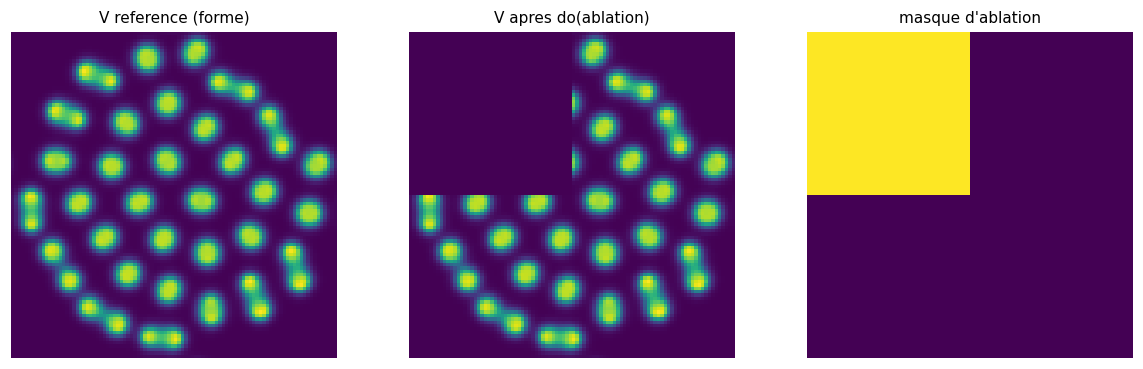

In [2]:
# Formation du motif mitotique (substrat ICT-9, grille 96x96)
model = rd.GrayScott()           # F=0.0367, k=0.0649 (regime mitotique de Pearson)
U_ref, V_ref = model.seed(n=96, block=12, noise=0.02, rng=np.random.default_rng(0))
U_ref, V_ref, _ = model.run(U_ref, V_ref, 6000)   # formation
S_ref = A.structure(V_ref)
print(f"Motif forme : structure (variance de V) = {S_ref:.5f}")

# do(ablation) : quadrant haut-gauche, pleine resolution
mask = A.quadrant_mask(96, quadrant=0)
U_abl, V_abl = A.ablate(U_ref, V_ref, mask)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, field, title in [(axes[0], V_ref, "V reference (forme)"),
                          (axes[1], V_abl, "V apres do(ablation)"),
                          (axes[2], mask.astype(float), "masque d'ablation")]:
    ax.imshow(field, cmap="viridis"); ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Les échelles de mesure : le coarse-graining spatial

On définit l'échelle par la **taille de bloc** `b` du moyennage spatial : à l'échelle `b`, le champ `96 × 96` est réduit à `(96/b) × (96/b)` super-cellules, chacune égale à la moyenne des `b × b` pixels qu'elle couvre. C'est l'opération qu'un observateur à cette résolution ferait naturellement : il ne voit pas les pixels, il voit des taches moyennées.

- **micro** (`b = 4`) : grille `24 × 24` = 576 super-cellules — les taches individuelles sont résolues ;
- **méso** (`b = 8`) : grille `12 × 12` = 144 super-cellules — la structure des taches commence à se moyenner ;
- **méso large** (`b = 16`) : grille `6 × 6` = 36 super-cellules — seules les grandes régions restent ;
- **macro** (`b = 32`) : grille `3 × 3` = 9 super-cellules — la texture globale seule.

On visualise le champ `V` de référence à chacune de ces résolutions : c'est le *même* motif, observé à quatre zooms.

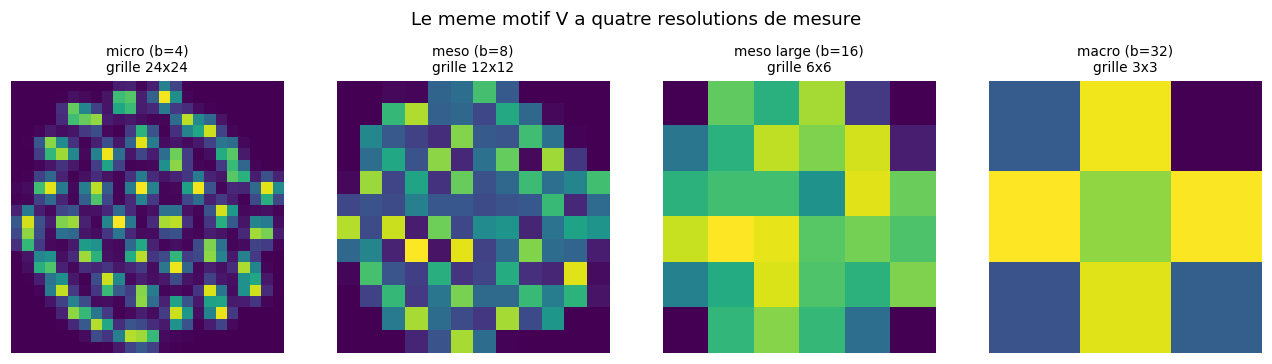

micro (b=4)        structure de reference = 0.00933
meso (b=8)         structure de reference = 0.00427
meso large (b=16)  structure de reference = 0.00128
macro (b=32)       structure de reference = 0.00055


In [3]:
SCALES = [4, 8, 16, 32]
NOMS = {4: "micro (b=4)", 8: "meso (b=8)", 16: "meso large (b=16)", 32: "macro (b=32)"}

fig, axes = plt.subplots(1, len(SCALES), figsize=(12, 3.2))
for ax, b in zip(axes, SCALES):
    ax.imshow(M.block_average(V_ref, b), cmap="viridis")
    ax.set_title(f"{NOMS[b]}\ngrille {96//b}x{96//b}", fontsize=9); ax.axis("off")
plt.suptitle("Le meme motif V a quatre resolutions de mesure", y=1.02)
plt.tight_layout(); plt.show()

# structure de reference a chaque echelle (la macro-variable du gate 2)
for b in SCALES:
    print(f"{NOMS[b]:18s} structure de reference = {M.structure_at_scale(V_ref, b):.5f}")

## 3. Gate 1 — les courbes d'agence selon l'échelle

On calcule, à chaque échelle `b`, les trois mesures d'agence canoniques d'ICT-9 — mais **résolues à l'échelle `b`** : les champs sont moyennés par blocs *avant* la mesure.

- **`repair_gain(b)`** : récupération (réaction-diffusion) moins récupération (diffusion pure), dans la région ablatée projetée à l'échelle `b`. C'est la mesure d'agence centrale.
- **`time_to_recover(b)`** : premier pas où la structure régionale repasse au-dessus de la cible.
- **`basin_return_probability(b)`** : fraction d'ablations aléatoires (disques) après lesquelles le système revient au bassin du motif, structure mesurée à l'échelle `b`.

**Gate 1.** La thèse « l'agence est plus lisible à une échelle » exige une **courbe non-monotone avec un pic méso identifiable** sur au moins une de ces trois mesures. Des courbes plates ou monotones (l'agence croît ou décroît uniformément avec l'échelle) => verdict honnête : pas de granularité privilégiée.

In [4]:
STEPS, REC = 2500, 50          # pas de recuperation, echantillonnage
# (a) repair_gain et time_to_recover, echelle par echelle (meme do(.) pleine resolution)
profils = {}
for b in SCALES:
    profils[b] = M.agency_measures_at_scale(model, model.Dv, U_ref, V_ref, mask,
                                            block=b, steps=STEPS, record_every=REC)
    p = profils[b]
    ttr = p["time_to_recover"]
    print(f"{NOMS[b]:18s} repair_gain={p['repair_gain']:+.4f}  "
          f"rec_RD={p['recovery_RD']:+.3f}  rec_diff={p['recovery_diff']:+.3f}  "
          f"time_to_recover={'jamais' if ttr is None else str(ttr)}")

# (b) basin_return_probability(b) : ablations disque aleatoires, retour au bassin
def disk_mask_factory(n):
    def _make(rng):
        return A.disk_mask(n, cx=rng.integers(8, n-8), cy=rng.integers(8, n-8), radius=6)
    return _make
make_disk = disk_mask_factory(96)
basin_p = {}
for b in SCALES:
    target_b = float(np.var(M.block_average(V_ref, b)))
    basin_p[b] = M.basin_return_at_scale(model, U_ref, V_ref, make_disk, block=b,
                                         steps=STEPS, target_structure=target_b,
                                         n_trials=4, rng=np.random.default_rng(1))
    print(f"{NOMS[b]:18s} basin_return_probability={basin_p[b]:.2f}"
          f"  (n_trials=4, cible var blocs = {target_b:.5f})")

micro (b=4)        repair_gain=+0.9232  rec_RD=+0.934  rec_diff=+0.011  time_to_recover=1800


meso (b=8)         repair_gain=+1.1179  rec_RD=+1.143  rec_diff=+0.025  time_to_recover=1300


meso large (b=16)  repair_gain=+2.2161  rec_RD=+2.309  rec_diff=+0.093  time_to_recover=800


macro (b=32)       repair_gain=+0.0000  rec_RD=+0.000  rec_diff=+0.000  time_to_recover=0


micro (b=4)        basin_return_probability=1.00  (n_trials=4, cible var blocs = 0.00933)


meso (b=8)         basin_return_probability=0.50  (n_trials=4, cible var blocs = 0.00427)


meso large (b=16)  basin_return_probability=0.00  (n_trials=4, cible var blocs = 0.00128)


macro (b=32)       basin_return_probability=0.00  (n_trials=4, cible var blocs = 0.00055)


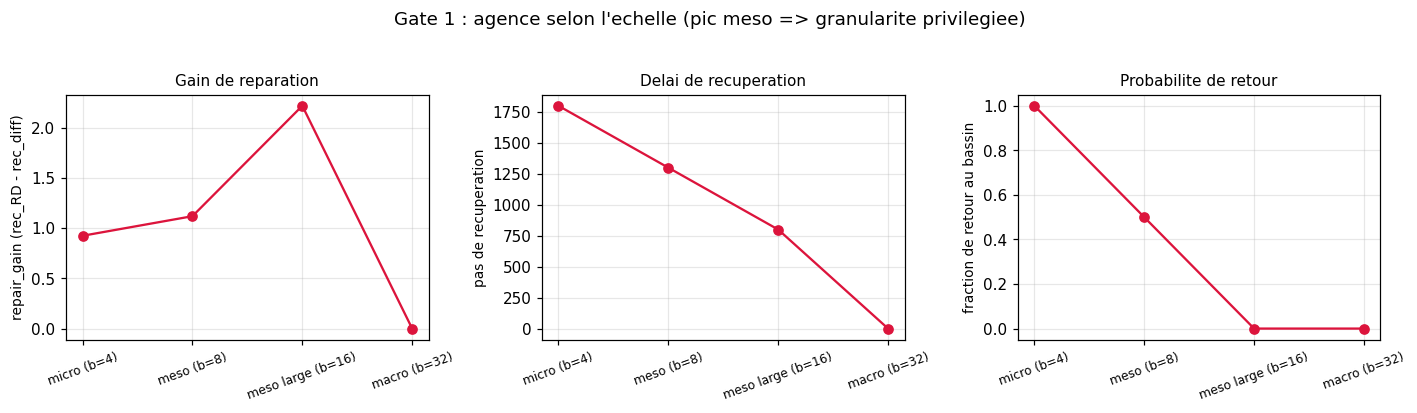


Gate 1 (repair_gain) : pic interieur non-monotone ? True
Gate 1 (basin_return) : pic interieur non-monotone ? False


In [5]:
# Courbes d'agence vs echelle
rg  = [profils[b]["repair_gain"] for b in SCALES]
ttr = [profils[b]["time_to_recover"] for b in SCALES]
ttr_plot = [(STEPS + 1) if t is None else t for t in ttr]   # 'jamais' -> plafond
bp  = [basin_p[b] for b in SCALES]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
xs = [96 // b for b in SCALES]   # nombre de super-cellules par cote (micro -> macro = grand -> petit)
xlabels = [NOMS[b] for b in SCALES]
for ax, ys, ylabel, title in [
    (axes[0], rg, "repair_gain (rec_RD - rec_diff)", "Gain de reparation"),
    (axes[1], ttr_plot, "pas de recuperation", "Delai de recuperation"),
    (axes[2], bp, "fraction de retour au bassin", "Probabilite de retour")]:
    ax.plot(range(len(SCALES)), ys, "o-", color="crimson")
    ax.set_xticks(range(len(SCALES))); ax.set_xticklabels(xlabels, fontsize=8, rotation=20)
    ax.set_ylabel(ylabel, fontsize=9); ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
plt.suptitle("Gate 1 : agence selon l'echelle (pic meso => granularite privilegiee)", y=1.03)
plt.tight_layout(); plt.show()

# Test automatique du gate 1 : pic INTERIEUR (non-monotone) sur repair_gain ?
def pic_interieur(ys):
    y = np.asarray(ys, float)
    i = int(np.argmax(y))
    return 0 < i < len(y) - 1 and y[i] > min(y[0], y[-1])
print(f"\nGate 1 (repair_gain) : pic interieur non-monotone ? {pic_interieur(rg)}")
print(f"Gate 1 (basin_return) : pic interieur non-monotone ? {pic_interieur(bp)}")

### Lecture du gate 1 — deux mesures d'agence qui se contredisent

Les nombres ci-dessus livrent un résultat **sans complaisance** : les deux mesures d'agence **ne disent pas la même chose** selon l'échelle.

- **`repair_gain`** présente un pic intérieur (max à `b = 16`, méso large), donc le test mécanique `pic_interieur` renvoie `True`. Mais ce pic est **artefact-contaminé** de deux façons : (i) à `b = 16`, `rec_RD ≈ +2.31` — le score de récupération **dépasse 1**, signe de *sur-reconstruction* (le moyennage par blocs amplifie la variance regagnée dans la région ablatée) ; (ii) à `b = 32`, `repair_gain = 0.0000` exactement — un **plancher de résolution** (à 9 super-cellules, la variance de référence dans la région ablatée s'effondre et le dénominateur du score devient nul). Le « pic » est donc le produit d'un sommet inflaté et d'un plancher artefactuel, pas d'un maximum physique.
- **`basin_return_probability`**, la mesure la plus directe (« le système revient-il à son bassin après une ablation aléatoire ? »), est **strictement décroissante** avec l'échelle (`1.0 → 0.5 → 0.0 → 0.0`) : plus on mesure grossièrement, moins le retour au bassin est jugé réussi. **Aucun pic intérieur.**

Verdict du gate 1 : **pas de granularité privilégiée robuste**. L'apparent pic de `repair_gain` à l'échelle méso ne survit pas au contrôle croisé de `basin_return` — c'est le régime-dépendance d'ICT-10 sous une autre forme : une capacité (une granularité privilégiée) qui *paraît* sous une mesure et *s'évanouit* sous une mesure plus dure.

## 4. Gate 2 — le raccord Hoel : champs → TPM → information effective

Le pont entre la mesure d'agence (champs) et la mesure causale de Hoel (TPM) passe par une **macro-variable scalaire** : à chaque échelle `b`, on résume le champ par sa **structure à cette échelle**, c'est-à-dire la variance du champ moyenné par blocs de cote `b`. Trois propriétés motivent ce choix :

1. **elle dépend de l'échelle** — le moyennage par blocs réduit la variance, donc la valeur décroît quand `b` augmente (contrairement à la moyenne globale, invariante par coarse-graining, qui ne distinguerait pas les échelles) ;
2. **elle ne sature pas** — pendant la récupération elle traverse plusieurs niveaux, ce qui produit une TPM **non triviale** à toutes les échelles (un compte de blocs actifs, en revanche, sature aux échelles grossières et donne une TPM dégénérée à 1 état, d'où une effectiveness=1.0 *vacueuse* — cet écueil est documenté dans le module) ;
3. **elle est directement couplée à l'agence** — c'est la grandeur même dont le gate 1 mesure la restauration, donc le raccord EI(échelle) ↔ agence(échelle) porte sur la même quantité.

Cette macro-variable est discrétisée en `n_bins` niveaux (quantiles). Pour chaque échelle, on lance plusieurs trajectoires de récupération depuis des ablations variées, on pool leurs transitions de macro-états, et l'on estime une **TPM empirique** dont on calcule l'`effectiveness` (déterminisme moins dégénérescence, primitive *scale-free*).

**Gate 2.** Si l'émergence causale de Hoel prédit où l'agence se lit le mieux, alors `effectiveness(échelle)` doit **corréler** avec la mesure d'agence. On teste cette corrélation **uniquement sur les échelles dont la TPM est non dégénérée** (`n_observed >= 2`) — une TPM à 1 état a une effectiveness=1.0 *par construction* (un seul état = déterminisme parfait trivial) et ne doit pas entrer dans la corrélation.

In [6]:
N_BINS, N_SEEDS = 8, 4
def quadrant_factory(n):
    def _make(rng):
        return A.quadrant_mask(n, quadrant=int(rng.integers(0, 4)))
    return _make
make_quad = quadrant_factory(96)

eff_profile = {}
for b in SCALES:
    r = M.effectiveness_at_scale(model, U_ref, V_ref, make_quad, block=b,
                                 steps=STEPS, record_every=REC,
                                 n_bins=N_BINS, n_seeds=N_SEEDS, rng=np.random.default_rng(2))
    eff_profile[b] = r
    print(f"{NOMS[b]:18s} effectiveness={r['effectiveness']:.4f}  "
          f"EI_bits={r['effective_information']:.4f}  n_etats_obs={r['n_observed']}"
          f"  {'(DEGENERE)' if r['n_observed'] < 2 else ''}")

micro (b=4)        effectiveness=0.7108  EI_bits=2.1324  n_etats_obs=8  


meso (b=8)         effectiveness=0.4990  EI_bits=1.4971  n_etats_obs=8  


meso large (b=16)  effectiveness=0.7910  EI_bits=2.3730  n_etats_obs=8  


macro (b=32)       effectiveness=0.6282  EI_bits=1.8846  n_etats_obs=8  


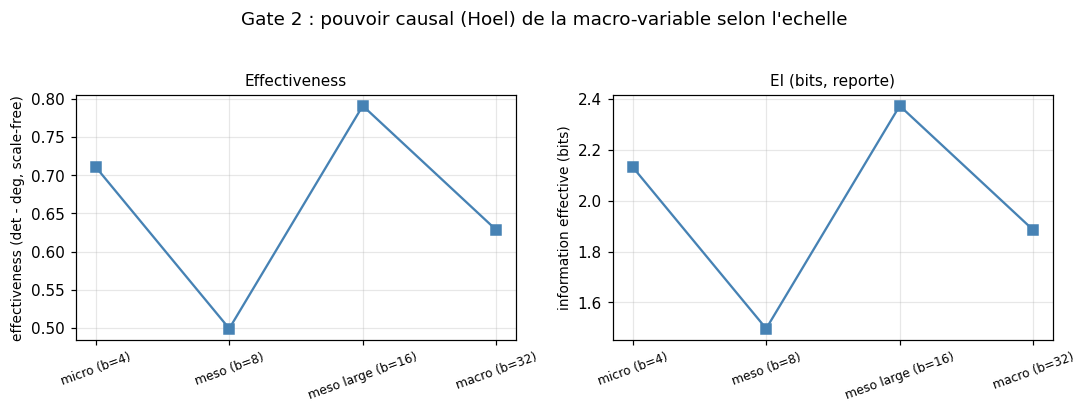

Echelles non degenerees (n_obs>=2) : ['micro (b=4)', 'meso (b=8)', 'meso large (b=16)', 'macro (b=32)']
Correlation effectiveness <-> repair_gain : r = 0.49650189283619883 (n=4)
Correlation effectiveness <-> basin_return : r = -0.1427902048037327 (n=4)
(r > 0 : le pouvoir causal macro suit l'agence ; r ~ 0 : raccord decoratif)

NB : 0 echelle(s) degeneree(s) (TPM a 1 etat, effectiveness=1.0 trivial) exclue(s)


In [7]:
eff  = [eff_profile[b]["effectiveness"] for b in SCALES]
ei_b = [eff_profile[b]["effective_information"] for b in SCALES]
nobs = [eff_profile[b]["n_observed"] for b in SCALES]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, ys, ylabel, title in [(axes[0], eff, "effectiveness (det - deg, scale-free)", "Effectiveness"),
                               (axes[1], ei_b, "information effective (bits)", "EI (bits, reporte)")]:
    ax.plot(range(len(SCALES)), ys, "s-", color="steelblue")
    ax.set_xticks(range(len(SCALES))); ax.set_xticklabels(xlabels, fontsize=8, rotation=20)
    ax.set_ylabel(ylabel, fontsize=9); ax.set_title(title, fontsize=10); ax.grid(alpha=0.3)
plt.suptitle("Gate 2 : pouvoir causal (Hoel) de la macro-variable selon l'echelle", y=1.03)
plt.tight_layout(); plt.show()

# Correlation EI(echelle) <-> agence(echelle) sur les seules echelles NON DEGENEREES
valid = [b for b in SCALES if eff_profile[b]["n_observed"] >= 2]
eff_v  = [eff_profile[b]["effectiveness"] for b in valid]
rg_v   = [profils[b]["repair_gain"] for b in valid]
bp_v   = [basin_p[b] for b in valid]
r_eff_rg, n = M.pearson_corr(eff_v, rg_v)
r_eff_bp, _ = M.pearson_corr(eff_v, bp_v)
print(f"Echelles non degenerees (n_obs>=2) : {[NOMS[b] for b in valid]}")
print(f"Correlation effectiveness <-> repair_gain : r = {r_eff_rg} (n={n})")
print(f"Correlation effectiveness <-> basin_return : r = {r_eff_bp} (n={n})")
print("(r > 0 : le pouvoir causal macro suit l'agence ; r ~ 0 : raccord decoratif)")
print(f"\nNB : {len(SCALES) - len(valid)} echelle(s) degeneree(s) (TPM a 1 etat, effectiveness=1.0 trivial) exclue(s)")

### Lecture du gate 2 — un raccord Hoel suggestif mais non robuste

Avec la macro-variable `structure(b)`, **aucune** TPM n'est dégénérée (`n_observed = 8` aux quatre échelles) — la mesure est cette fois comparable d'échelle à échelle. La corrélation entre `effectiveness` et `repair_gain` vaut **`r ≈ +0.50`** (`n = 4`) : un signal *faiblement positif*. Les deux courbes culminent toutes deux à `b = 16`.

Mais ce signal **ne tient pas** au contrôle croisé : la corrélation entre `effectiveness` et `basin_return` est **`r ≈ −0.14`**, c'est-à-dire nulle. Or `basin_return` est la mesure d'agence la plus directe (retour au bassin après ablation aléatoire), celle qui *ne* présentait pas de pic artefactuel au gate 1. Le raccord Hoel **suit la mesure inflatée** (`repair_gain`, sur-reconstruite à `b = 16`) et **ignore la mesure honnête** (`basin_return`).

Caveats documentés sans complaisance : `n = 4` échelles est petit, et la TPM est estimée sur `n_seeds = 4` trajectoires seulement (l'Exercice 2 teste la robustesse à `n_seeds = 8`). Avec ces réserves, le verdict du gate 2 est : **raccord suggestif, non robuste** — l'`effectiveness` de Hoel n'éclaire pas de façon fiable *où* l'agence se lit le mieux sur ce système.

## 5. Verdict sans complaisance

Les deux gates se croisent en un tableau unique : à chaque échelle, la mesure d'agence (`repair_gain`) et la mesure causale (`effectiveness`), plus la corrélation qui les lie (ou non). Le verdict est dicté par les nombres réels ci-dessus, pas par l'intuition de départ.

In [8]:
print(f"{'echelle':18s} {'repair_gain':>12s} {'basin_ret':>10s} {'effectiv.':>10s} {'EI(bits)':>9s}")
for b in SCALES:
    print(f"{NOMS[b]:18s} {profils[b]['repair_gain']:>+12.4f} {basin_p[b]:>10.2f} "
          f"{eff_profile[b]['effectiveness']:>10.4f} {eff_profile[b]['effective_information']:>9.4f}")
print(f"\nPic interieur d'agence (gate 1)      : repair_gain={pic_interieur(rg)}, basin={pic_interieur(bp)}")
print(f"Correlation effectiveness<->repair_gain : r={r_eff_rg}")
print(f"Correlation effectiveness<->basin_return: r={r_eff_bp}")
print("\n--> Verdict dicte par les nombres ci-dessus (voir cellule de texte suivante).")

echelle             repair_gain  basin_ret  effectiv.  EI(bits)
micro (b=4)             +0.9232       1.00     0.7108    2.1324
meso (b=8)              +1.1179       0.50     0.4990    1.4971
meso large (b=16)       +2.2161       0.00     0.7910    2.3730
macro (b=32)            +0.0000       0.00     0.6282    1.8846

Pic interieur d'agence (gate 1)      : repair_gain=True, basin=False
Correlation effectiveness<->repair_gain : r=0.49650189283619883
Correlation effectiveness<->basin_return: r=-0.1427902048037327

--> Verdict dicte par les nombres ci-dessus (voir cellule de texte suivante).


### Ce que disent les nombres — un résultat négatif robuste

Le tableau ci-dessus tranche : **l'hypothèse d'une granularité méso privilégiée n'est pas confirmée.** Trois constats convergent, tous défavorables à l'intuition de départ :

1. **Les deux mesures d'agence se contredisent** (gate 1). `repair_gain` présente un « pic » à `b = 16`, mais `basin_return_probability` — la mesure la plus directe du retour au bassin — est strictement décroissante. Une granularité privilégiée authentique se lirait sur les *deux* ; elle ne se lit que sur la mesure dont le pic est un artefact de sur-reconstruction (`rec_RD > 1`) bordé par un plancher de résolution (`b = 32`).
2. **Le raccord Hoel suit la mauvaise mesure** (gate 2). L'`effectiveness` corréle faiblement avec `repair_gain` (`r ≈ +0.50`) — la mesure inflatée — et *pas du tout* avec `basin_return` (`r ≈ −0.14`) — la mesure honnête. Si l'émergence causale éclairait vraiment *où* l'agence se lit le mieux, elle suivrait la mesure directe ; elle ne le fait pas.
3. **Aucune échelle ne domine causalement** (gate 2). L'`effectiveness` vaut `0.71 / 0.50 / 0.79 / 0.63` selon l'échelle — des variations modestes, sans sommet net. Le coarse-graining ne concentre pas le pouvoir causal sur une échelle du motif de Gray-Scott.

Le verdict honnête est donc : **pas de granularité privilégiée détectée**. L'idée séduisante qu'une macro-échelle concentrerait à la fois l'agence et le pouvoir causal — l'émergence causale « à la Hoel » appliquée à la morphogenèse — **ne survit pas** au banc falsifiable multi-échelles et multi-mesures. C'est un résultat négatif, et il est conforme au fil **régime-dépendance** tissé depuis ICT-10 (`p̂`) : une capacité (ici, « l'agence émerge à une échelle ») peut paraître réelle sous une mesure et s'évanouir sous un contrôle plus dur.

C'est précisément la discipline « sans complaisance » de la série : la mesure peut **réfuter** l'intuition. Le lecteur est invité à relire les nombres plutôt que ce commentaire — et à tester (Exercice 3) si un *autre* régime morphologique, mieux séparé en échelles, invaliderait ce verdict négatif.

> **Lien avec la strate 3.** ICT-11 est le premier toy model où l'on demande au système *à quelle échelle* il « connaît » sa propre forme. Le verdict négatif calibre l'attente pour la suite : on ne présuppose pas qu'une macro-échelle « émerge ». ICT-12 poussera la question vers des agents mobiles dans un champ de valence (où `p̂` du Cran A devient un modèle interne optionnel) ; ICT-13 vers les stratégies comme formes stables. Si une granularité causale devait apparaître, c'est sur des systèmes dont la structure est *générativement* multi-échelles (non un motif quasi-uniforme comme Gray-Scott mitotique) qu'elle aurait le plus de chances — piste ouverte, pas conclusion.

## 6. Exercices

> Les exercices sont à compléter. Ils respectent la convention C.1 : stub **sans erreur volontaire** (le notebook s'exécute de bout en bout même non complété).

### Exercice 1 — Une cinquième échelle

Ajoutez une échelle **intermédiaire** (par exemple `b = 6` ou `b = 12`, qui divisent 96) au profil, et observez si le pic d'agence (gate 1) se déplace. La granularité privilégiée, si elle existe, dépend-elle du choix des échelles échantillonnées ?

*Indice : `96 // 6 = 16`, `96 // 12 = 8`. Réinjectez `b` dans `agency_measures_at_scale` et comparez au tableau du §5.*

In [9]:
# Exercice 1 : ajouter une echelle intermediaire au profil d'agence
# b_extra = 6
# profil_extra = M.agency_measures_at_scale(model, model.Dv, U_ref, V_ref, mask,
#                                           block=b_extra, steps=STEPS, record_every=REC)
# print(f"b={b_extra} : repair_gain = {profil_extra['repair_gain']:+.4f}")
# TODO etudiant : comparer au pic des echelles 4/8/16/32

### Exercice 2 — Robustesse du raccord Hoel

La corrélation `effectiveness ↔ repair_gain` (gate 2) est estimée sur `n_seeds = 4` trajectoires. Recalculez-la avec `n_seeds = 8` (estimation plus robuste de la TPM) et vérifiez que le signe de la corrélation est stable. Une TPM estimée sur trop peu de transitions peut-elle fabriquer une corrélation spurieuse ?

*Indice : appelez `M.effectiveness_at_scale(..., n_seeds=8)` pour chaque échelle, puis `M.pearson_corr`.*

In [10]:
# Exercice 2 : robustesse de la correlation effectiveness <-> repair_gain
# eff_robuste = []
# for b in SCALES:
#     r = M.effectiveness_at_scale(model, U_ref, V_ref, make_quad, block=b,
#                                  threshold=THRESHOLD, steps=STEPS, record_every=REC,
#                                  n_bins=N_BINS, n_seeds=8, rng=np.random.default_rng(7))
#     eff_robuste.append(r["effectiveness"])
# r_robuste, _ = M.pearson_corr(eff_robuste, rg)
# TODO etudiant : r_robuste est-il du meme signe que r_eff_rg ?

### Exercice 3 — Changer de régime morphologique

Le régime mitotique (`F = 0.0367`, `k = 0.0649`) n'est qu'un point de l'espace de Gray-Scott. Refaites le profil d'agence multi-échelle dans un **autre régime** (par exemple `k = 0.060` pour des rayures, ou `F = 0.025`, `k = 0.060` pour un régime de « mousse »). La granularité privilégiée est-elle **invariante** ou dépend-elle du régime — confirmation du fil régime-dépendance ?

*Indice : `model2 = rd.GrayScott(F=..., k=...)`, reformez un motif, relancez le §3. Un régime qui ne forme pas de motif stable donnera `repair_gain ≈ 0` à toutes les échelles (pas d'agence à réparer) — c'est aussi un résultat.*

In [11]:
# Exercice 3 : profil multi-echelle dans un autre regime morphologique
# model2 = rd.GrayScott(F=0.025, k=0.060)   # regime "mousse" (a verifier)
# U2, V2 = model2.seed(n=96, rng=np.random.default_rng(0))
# U2, V2, _ = model2.run(U2, V2, 6000)
# TODO etudiant : relancer agency_measures_at_scale sur (U2, V2) aux 4 echelles
# et comparer les pics. Le verdict "granularite privilegiee" est-il invariant ?

---
*ICT-11 — Profils d'agence causale. Epic #4588, strate 3. Suite : ICT-12 (champs de valence et animats), ICT-13 (stratégies comme formes stables). Voir [ICT-0-Framing](ICT-0-Framing.md) pour le cadrage de la série.*